# Nearest neighbor classification

NN classification is one of the simplest machine learning approaches:

*Given a test instance, pick the label of the closest training datapoint.*

- Assumption: each training point is the best indicator of the label of points in its neighborhood
- _Non-parametric_ method of machine learning
- We assume no explicit distribution
- To update "model", just add/remove training data
- We must define **distance**

# Distances

If features $\mathbf{x}_i \in \mathbb{R}^p$, then some sensible distances could be:
- Euclidean: $d(\mathbf{x}_i,\mathbf{x}_j) := \|\mathbf{x}_i - \mathbf{x}_j\|_2$
- Weighted Euclidean: $d(\mathbf{x}_i,\mathbf{x}_j) := \|\mathbf{W}(\mathbf{x}_i - \mathbf{x}_j)\|_2$
- Manhattan: $d(\mathbf{x}_i,\mathbf{x}_j) := \|\mathbf{x}_i - \mathbf{x}_j\|_1$

If your data is not described by numercial features, then differences between some dimensions might not make sense, e.g., "male" - "female".

You've already seen a model that can work with categorical data: decision tree!

We will learn about another next time (Naive Bayes)

# Preliminaries

To get intuition for nearest neighbor classification, let's synthesize a "toy" dataset of numerical features.

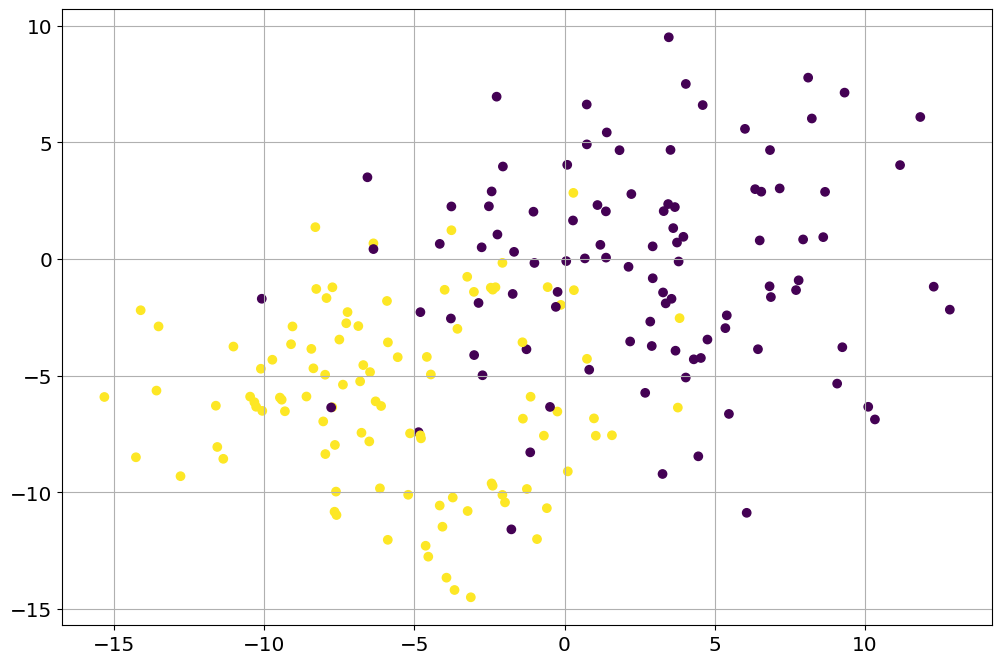

In [75]:
import numpy as np
from sklearn import datasets 
import matplotlib.pyplot as plt

numClasses = 2 # number of separate classes
numObservations = numClasses*10000 # number of total observations
cluster_std = 4 # spread of the classes, larger leads to more confusion

# create a labeled dataset and make a pandas dataframe
Xbig,ybig = datasets.make_blobs(numObservations,centers=numClasses,
                                cluster_std=cluster_std)

# The following makes the plot look nice
params = {'legend.fontsize': 'x-large','figure.figsize': (12, 8),
         'axes.labelsize': 'x-large','axes.titlesize':'x-large',
         'xtick.labelsize':'x-large','ytick.labelsize':'x-large'}
plt.rcParams.update(params)
# We will look at a subset first
X = Xbig[0:200]
y = ybig[0:200]
# make a scatter plot of the dataset
fig, ax = plt.subplots()
plt.scatter(X[:,0],X[:,1],c=y)
plt.grid()
plt.show()

# Partition data

We now create an 80/20 train/test split of the data.

In [76]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Create an instance of NN classifier


In [77]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=1)

Note that the default distance is Euclidean
https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html

# Train the NN classifier


In [78]:
clf.fit(X_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",1
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


This just casts the training dataset into an efficiently searchable database.

# Decision boundary

Let's now plot the decision boundary of the NN classifier.

<Axes: >

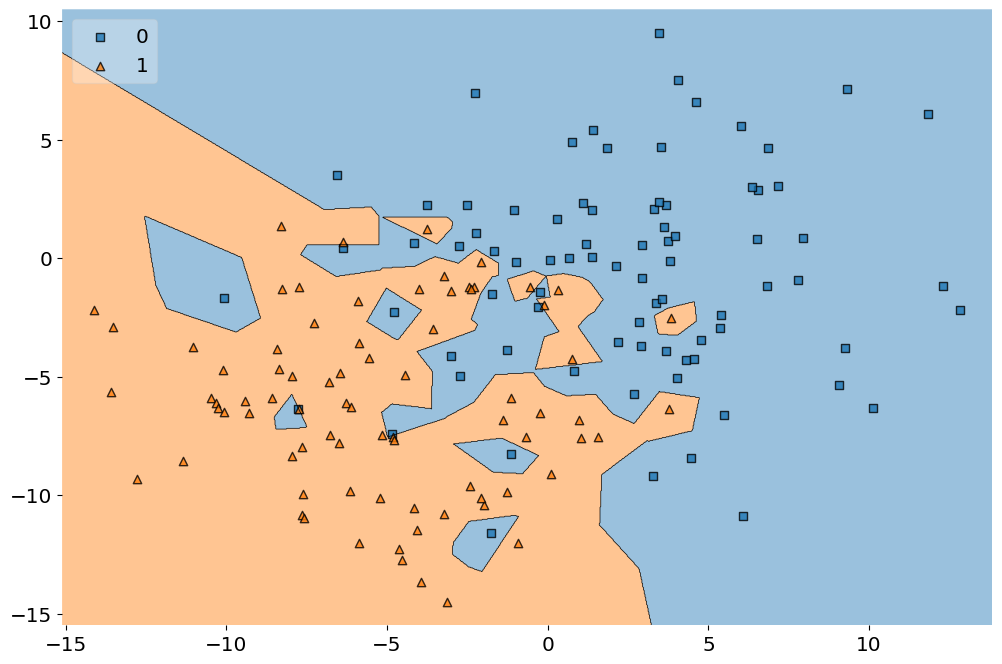

In [79]:
# install the mlxtend package for the following to work
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(X_train, y_train, clf=clf, legend=2)

# Testing the NN classifier

Let's apply the NN classifier to the test set and measure its performance.

In [80]:
predictions = clf.predict(X_test)
print("Test set predictions:", predictions)
print("Test set labels:", y_test)
from sklearn.metrics import confusion_matrix
confusion = confusion_matrix(y_test, predictions)
print(confusion)
from sklearn.metrics import classification_report
print(classification_report(y_test, clf.predict(X_test)))

Test set predictions: [1 1 0 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 0 1 1 1 0 1 1 0 1 0 1 1 1 0 1 0 1 0 0
 0 1 1]
Test set labels: [1 1 0 1 0 1 0 0 1 1 0 0 0 0 0 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 0 1 0 1 1 0
 0 1 1]
[[15  3]
 [ 3 19]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        18
           1       0.86      0.86      0.86        22

    accuracy                           0.85        40
   macro avg       0.85      0.85      0.85        40
weighted avg       0.85      0.85      0.85        40



# Decision boundary variation

How much does the decision boundary change with a different 80/20 partitionings of the dataset?

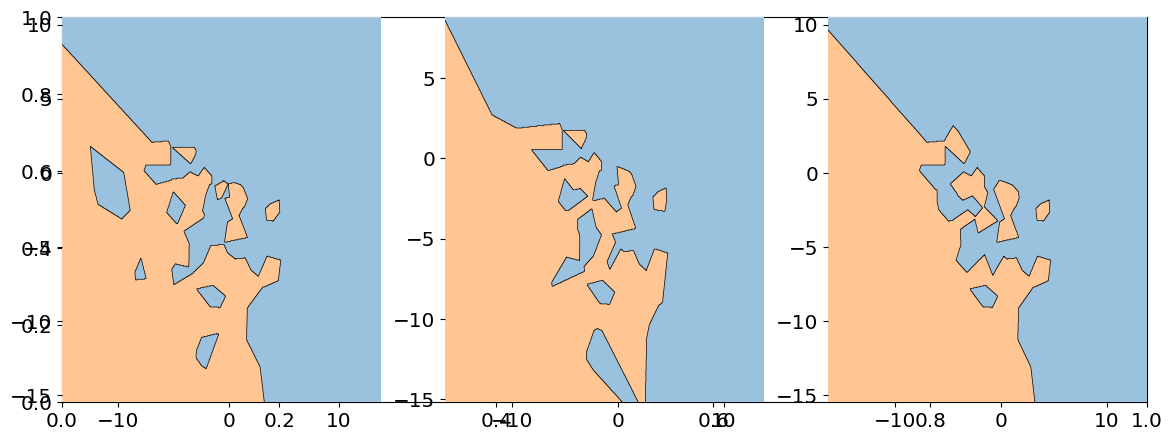

In [81]:
params = {'legend.fontsize': 'x-large','figure.figsize': (14, 5),
         'axes.labelsize': 'x-large','axes.titlesize':'x-large',
         'xtick.labelsize':'x-large','ytick.labelsize':'x-large'}
plt.rcParams.update(params)

fig, ax = plt.subplots()
plt.subplot(1,3,1)
plot_decision_regions(X_train, y_train, clf=clf, legend=0, scatter_kwargs={'alpha':0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
clf.fit(X_train,y_train)
plt.subplot(1,3,2)
plot_decision_regions(X_train, y_train, clf=clf, legend=0, scatter_kwargs={'alpha':0})
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
clf.fit(X_train,y_train)
plt.subplot(1,3,3)
plot_decision_regions(X_train, y_train, clf=clf, legend=0, scatter_kwargs={'alpha':0})
plt.show()

# Variance in decision boundary as dataset grows

As the size of the training data gets larger, the variation in the decision boundary due to partitioning decreases.

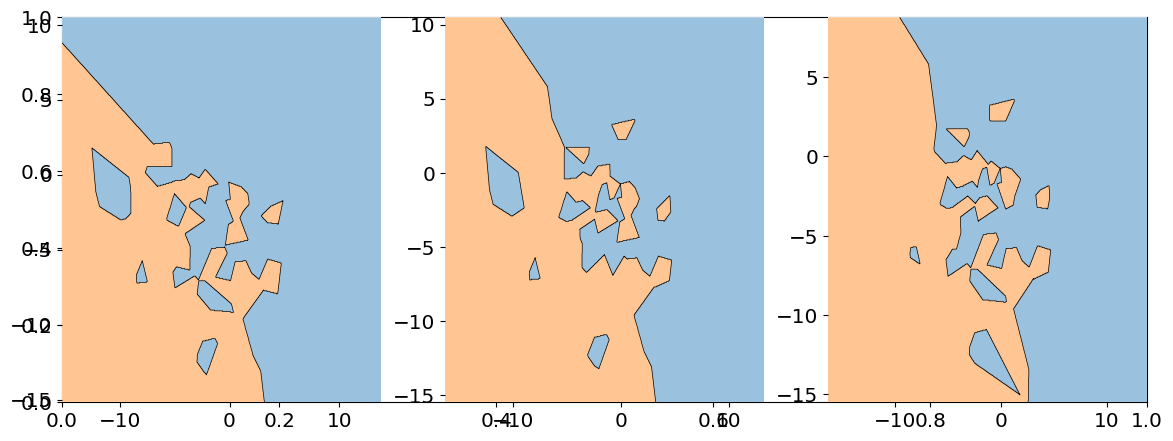

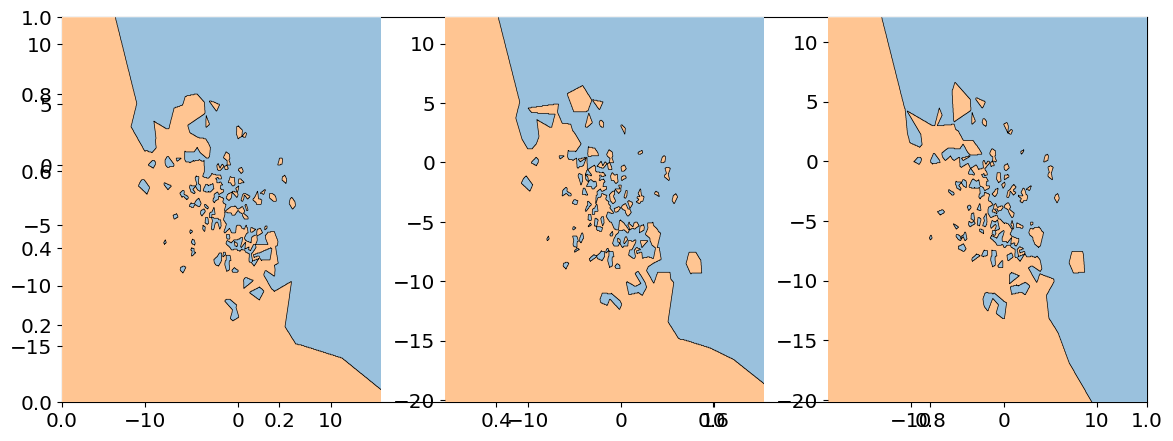

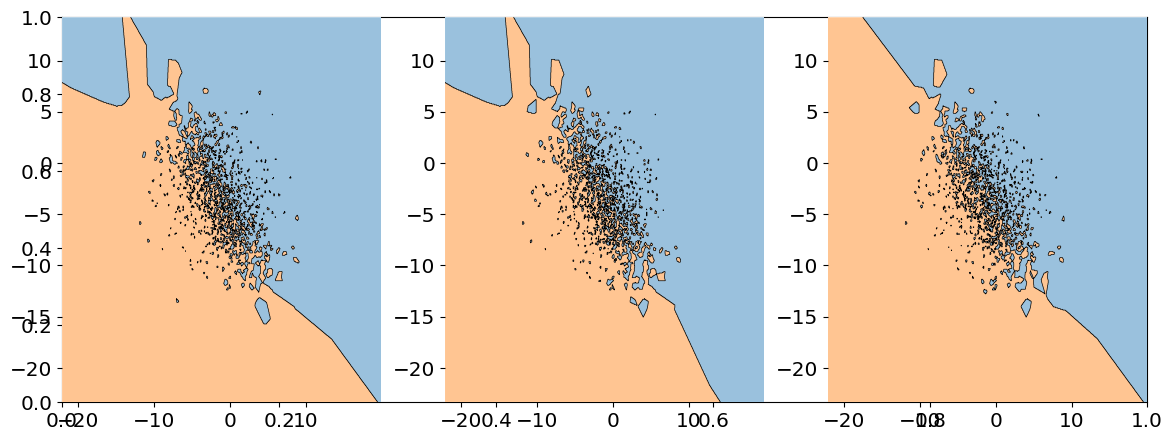

In [82]:
def create_plots(X,y):
    fig, ax = plt.subplots()
    for jj in range(1,3+1):
        plt.subplot(1,3,jj)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
        clf.fit(X_train,y_train)
        plot_decision_regions(X_train, y_train, clf=clf, legend=0, scatter_kwargs={'alpha':0})
    plt.show()

create_plots(Xbig[0:200],ybig[0:200])
create_plots(Xbig[0:2000],ybig[0:2000])
create_plots(Xbig,ybig)

## Let's apply NN to the Iris dataset

In [86]:
from sklearn.datasets import load_iris
iris_dataset = load_iris()

X = iris_dataset['data']
Y = iris_dataset['target']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, train_size=0.8)

from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier(n_neighbors=1)
clf.fit(X_train,y_train)

from sklearn.metrics import classification_report
print(classification_report(y_test, clf.predict(X_test),target_names=iris_dataset.target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         5
  versicolor       0.92      0.92      0.92        12
   virginica       0.92      0.92      0.92        13

    accuracy                           0.93        30
   macro avg       0.95      0.95      0.95        30
weighted avg       0.93      0.93      0.93        30



# Considering more neighbors

It makes sense to think that querying the class membership of $K>1$ neighbors increases robustness:

*Given a test instance, pick the majority/average label of the $K$ closest training datapoints.*

- But how large should $K$ be?
- What will happen to the decision boundary?

# kNN: From one neighbor to a neighborhood

- Well, one neighbor might be wrong, it should be better to ask more of them for their opinion!?!
- Result, when increasing k: 
    - the decision boundary becomes simpler
    - the model fits less exactly to our training data

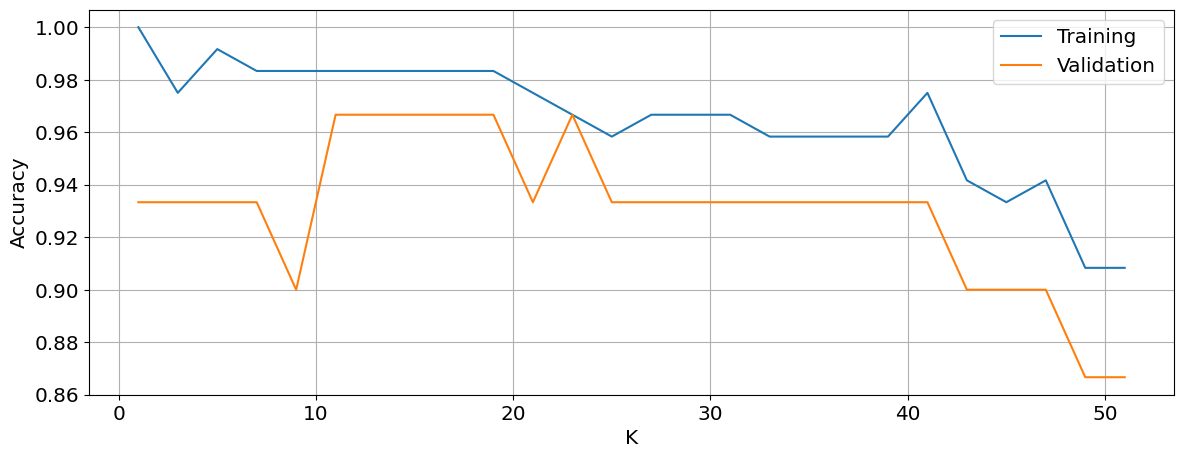

In [87]:
acc_train = []
acc_test = []

K = range(1,53,2)
for kk in K:
    clf = KNeighborsClassifier(n_neighbors=kk)
    clf.fit(X_train, y_train)
    acc_train.append(clf.score(X_train,y_train))
    acc_test.append(clf.score(X_test,y_test))
    
fig, ax = plt.subplots()
plt.plot(K,acc_train)
plt.plot(K,acc_test)
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend(['Training','Validation'])
plt.grid()
plt.show()

## Generalization, Overfitting, and Underfitting

* If a model is able to make accurate predictions on unseen data: 
    * it is able to **generalize** from the training set to the test set.
* Building a model that is too complex for the amount of information in the data is called overfitting.
* This refers to the complexity of the decision boundary, **NOT** computational complexity.

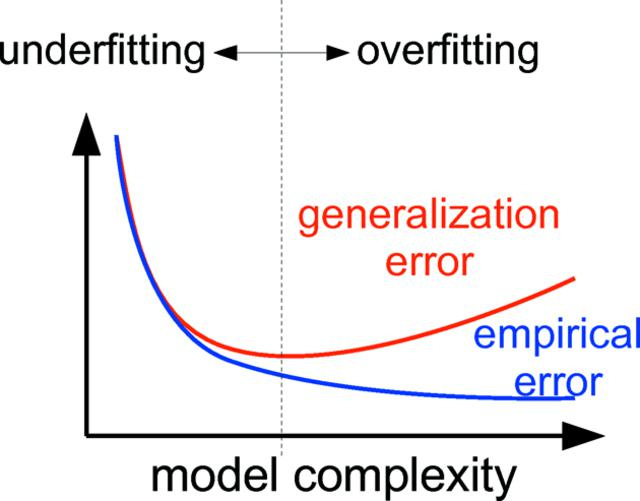

## Let's try another dataset

In [89]:
from sklearn.datasets import load_breast_cancer
cancer_dataset = load_breast_cancer()
print("Keys of cancer dataset:\n", cancer_dataset.keys())
print("Target names:", cancer_dataset['target_names'])
print("Feature names:\n", cancer_dataset['feature_names'])
print("Shape of data:", cancer_dataset['data'].shape)
print("Target:\n", cancer_dataset['target'])

Keys of cancer dataset:
 dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
Target names: ['malignant' 'benign']
Feature names:
 ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Shape of data: (569, 30)
Target:
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1


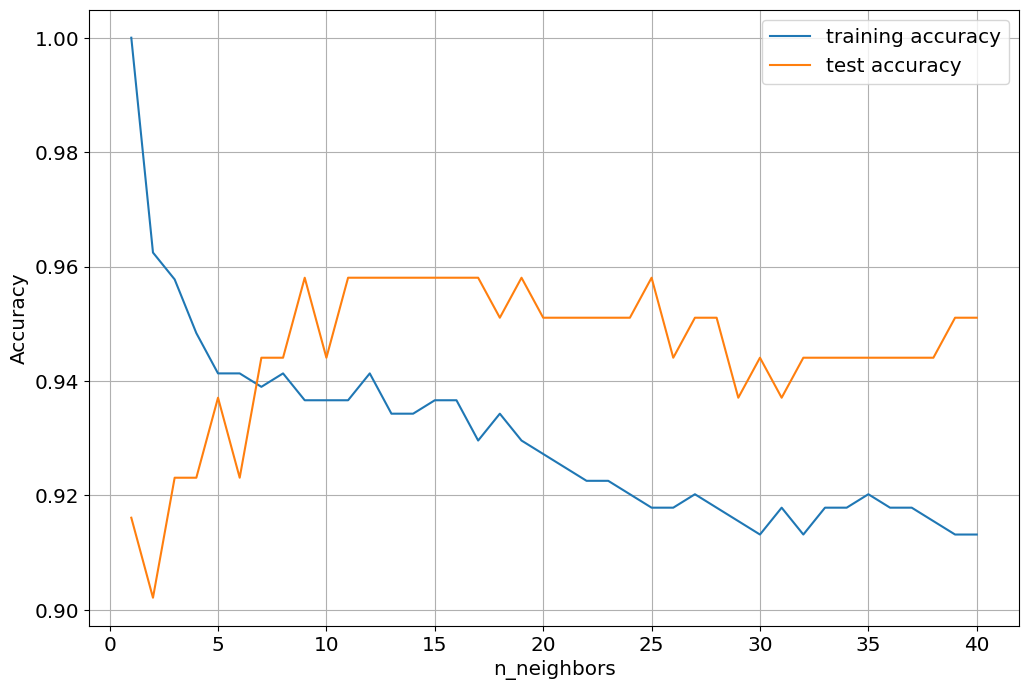

The maximum accuracy of for the test set is achieved for k=9,     so I would use this value


In [91]:
X_trainI, X_testI, y_trainI, y_testI = train_test_split(
    cancer_dataset['data'], cancer_dataset['target'], random_state=0)
training_accuracy = []
test_accuracy = []
# try n_neighbors from 1 to 41
neighbors_settings = range(1, 41)

for n_neighbors in neighbors_settings:
    # build the model
    clf = KNeighborsClassifier(n_neighbors=n_neighbors)
    clf.fit(X_trainI, y_trainI)
    # record training set accuracy
    training_accuracy.append(clf.score(X_trainI, y_trainI))
    # record generalization accuracy
    test_accuracy.append(clf.score(X_testI, y_testI))

plt.figure(figsize=(12, 8))
plt.plot(neighbors_settings, training_accuracy, label="training accuracy")
plt.plot(neighbors_settings, test_accuracy, label="test accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()
plt.grid()
plt.show()

print("The maximum accuracy of for the test set is achieved for k={}, \
    so I would use this value".format(neighbors_settings[np.argmax(test_accuracy)]))

#variables for later:
neighbors_settings_single = range(1, 101)
training_accuracy_single = training_accuracy
test_accuracy_single = test_accuracy


- Overfitting happens for small values of k!
- Complexity decreases from left to right (opposite of the theoretical plot!)
- The sweet spot is somewhere between 9 and 15.
- Question: Why is the training accuracy for k=1 perfect?

## Cross-Validation in scikit-learn (5.1.1)



*   Use the cross_val_score function to apply the above depicted procedure.
*   Here, we apply it on the cancer dataset, and use kNN.
*   It is common to compute the mean accuracy over the n folds.



In [92]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
clf = KNeighborsClassifier(n_neighbors=9)
cv = StratifiedKFold(n_splits=5,shuffle=True)
scores = cross_val_score(clf, cancer_dataset.data, cancer_dataset.target, cv=cv)
print("Cross-validation scores: {}".format(scores))
print("Average cross-validation score: {}".format(scores.mean()))

Cross-validation scores: [0.92105263 0.90350877 0.95614035 0.93859649 0.96460177]
Average cross-validation score: 0.9367800031051079


- The average we obtain using 5-fold cross-validation (0.93) is smaller than what we got using a single split (0.96)!
- we can be lucky when doing one train-test split.



*   As an alternative, use cross_validate, which provides you with more detailed information.
*   These information can be nicely processed and illustrated using pandas.



In [93]:
import pandas as pd
from sklearn.model_selection import cross_validate
cv = StratifiedKFold(n_splits=5,shuffle=True)
res = cross_validate(clf, cancer_dataset.data, \
                     cancer_dataset.target, cv=cv,return_train_score=True)

display(res)
# use pandas
res_df = pd.DataFrame(res)
display(res_df)
print("Mean times and scores:\n", res_df.mean())

{'fit_time': array([0.00103807, 0.00075293, 0.00043583, 0.00061226, 0.0004108 ]),
 'score_time': array([0.00402904, 0.00229812, 0.00174284, 0.00137377, 0.0012691 ]),
 'test_score': array([0.92982456, 0.92982456, 0.96491228, 0.93859649, 0.89380531]),
 'train_score': array([0.93626374, 0.93846154, 0.93406593, 0.93406593, 0.95614035])}

,fit_time,score_time,test_score,train_score
0,0.001038,0.004029,0.929825,0.936264
1,0.000753,0.002298,0.929825,0.938462
2,0.000436,0.001743,0.964912,0.934066
3,0.000612,0.001374,0.938596,0.934066
4,0.000411,0.001269,0.893805,0.956140


Mean times and scores:
 fit_time       0.000650
score_time     0.002143
test_score     0.931393
train_score    0.939799
dtype: float64


## Benefits of Cross-Validation (5.1.2)



*   We avoid the risk of being lucky or unlucky in the random choice of train and test data.
*   Variation of accuracy between the folds gives some insight to best and worst case scenarios.
*   Disadvantage: Increased computational cost of evaluation.

Note: Cross validation is not a method to obtain a trained model, but rather to see how well a specific algorithm generalizes given a specific dataset.



# Grid Search (5.2)

*  Usually, we do not only want to test a specific model, but...
*  ...first, we want to identify model parameters that lead to good performance!
*  for instance the number for k in kNN

Note: other algorithms have much more parameters than just one.


## Our kNN with k=13 performed great! 

*  Be skeptical when your accuracies approach 100% :)
*  Our mistake: we used testing data to optimize parameters!
*  Remember: testing data is used to check generalization...
*  we need to partition our data into three pieces when optimizing parameters

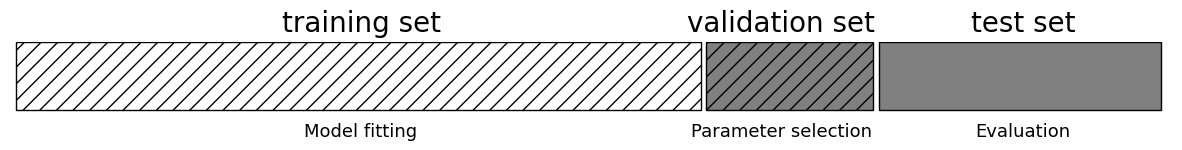

In [94]:
import mglearn
mglearn.plots.plot_threefold_split()

In [95]:
# split data into train+validation set and test set
X_trainval, X_test, y_trainval, y_test = train_test_split(
    cancer_dataset.data, cancer_dataset.target, random_state=0)
# split train+validation set into training and validation sets
X_train, X_valid, y_train, y_valid = train_test_split(
    X_trainval, y_trainval, random_state=1)
print("Size of training set: {}   size of validation set: {}   size of test set:"
      " {}\n".format(X_train.shape[0], X_valid.shape[0], X_test.shape[0]))

best_score = 0
neighbors_settings = range(1, 100)

# note: if your model has several parameters, you test them in nested for-loops (which is why this is called a GRID)
for nn in neighbors_settings:
    # for each value get a model
    clf = KNeighborsClassifier(n_neighbors=nn)
    clf.fit(X_train, y_train)
    # evaluate the kNN on the validation set
    score = clf.score(X_valid, y_valid)
    # if we got a better score, store the score and parameters
    if score > best_score:
        best_score = score
        best_hyperparameter = {'n_neighbors': nn}

# rebuild a model on the combined training and validation set,
# and evaluate it on the test set
clf = KNeighborsClassifier(**best_hyperparameter)
clf.fit(X_trainval, y_trainval)
test_score = clf.score(X_test, y_test)
print("Best score on validation set: {:.2f}".format(best_score))
print("Best hyperparameter: ", best_hyperparameter)
print("Test set score with best hyperparameter: {:.2f}".format(test_score))

Size of training set: 319   size of validation set: 107   size of test set: 143

Best score on validation set: 0.95
Best hyperparameter:  {'n_neighbors': 8}
Test set score with best hyperparameter: 0.94


* We see that the validation score is higher than the test score:
    * This indicates that it is a good idea to separate parameter tuning and testing!
* Can we use cross-validation for selecting hyperparameters?

## Grid Search with Cross-Validation (5.2.3)

* Using only one partitioning into training, validation, and test can create large fluctuations depending on this partitioning.
* -> we often combine grid search and cross validation to avoid this
* However, then we train and evaluate $N_{neighbors} \times N_{crossval}$ models (here: 100x5=500!)

In [96]:
best_score = 0
for nn in neighbors_settings:
        # for each parameter setting, train a model
        clf = KNeighborsClassifier(n_neighbors=nn)
        # perform cross-validation
        scores = cross_val_score(clf, X_trainval, y_trainval, cv=5)
        # compute mean cross-validation accuracy
        score = np.mean(scores)
        # if we got a better score, store the score and parameters
        if score > best_score:
            best_score = score
            best_hyperparameter = {'n_neighbors': nn}
# rebuild a model on the combined training and validation set
clf = KNeighborsClassifier(**best_hyperparameter)
clf.fit(X_trainval, y_trainval)
test_score = clf.score(X_test, y_test)
print("Best score on validation set: {:.2f}".format(best_score))
print("Best hyperparameter: ", best_hyperparameter)
print("Test set score with best hyperparameter: {:.2f}".format(test_score))

Best score on validation set: 0.94
Best hyperparameter:  {'n_neighbors': 14}
Test set score with best hyperparameter: 0.96


The GridSearchCV class nicely reduces this procedure to a few steps (Ch. 5.2.3):

1. Define the grid parameters
2. Instantiate GridSearchCV with the type of classifier, the parameters, and the type of cross validation.
3. Divide data into training and testing sets.
4. Calling fit() to conduct grid search and cross validation.
5. Get the results of the best classifier.


In [97]:
#1.
param_grid = {'n_neighbors': np.arange(1,101)}
#2.
from sklearn.model_selection import GridSearchCV
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, return_train_score=True)
#3.
X_train, X_test, y_train, y_test = train_test_split(cancer_dataset.data, 
                                                    cancer_dataset.target, random_state=0)
#4.
grid_search.fit(X_train, y_train)
#5.
print("Test set score: {:.2f}".format(grid_search.score(X_test, y_test)))
print("Best hyperparameter: {}".format(grid_search.best_params_))

Test set score: 0.96
Best hyperparameter: {'n_neighbors': 14}


# Conclusion

- The division into train, validation, and test set enables us to 
    - optimize model parameters (validation set)
    - get a generalization performance
- The combination of grid search and cross-validation provides robust estimates for both.
- Cross-validation provides more robust estimates of model performance than a single fold.
- The whole procedure in a summary:


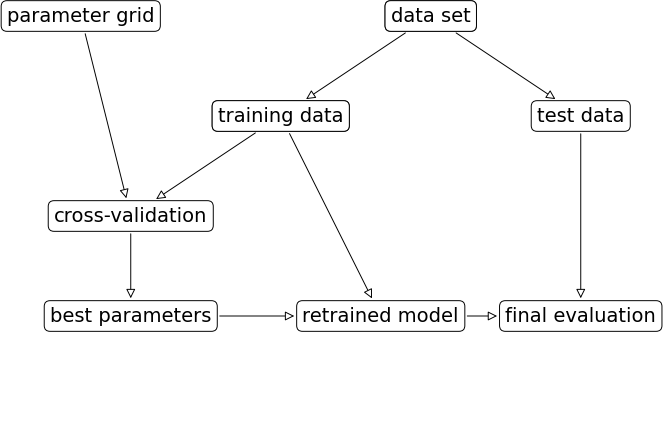

In [72]:
mglearn.plots.plot_grid_search_overview()